# Student Performance Factors Dataset — Exploración, limpieza y preparación

**Actividad:** Simulador integrador / preparación de datos para un posible problema de regresión.

> **Fuente:** Abdel-Ghany, M. (2025). *Student Performance Factors Dataset*. Kaggle.  
> **Liga:** https://www.kaggle.com/datasets/mosapabdelghany/student-performance-factors-dataset  
> **Fecha de consulta:** 15 de agosto de 2026.  
> **Última actualización reportada en Kaggle:** debe verificarse directamente en la ficha de Kaggle antes de entregar, porque no fue posible recuperar de forma verificable ese metadato desde la página consultada.

El conjunto representa estudiantes y diversos factores académicos, personales, familiares y escolares asociados con su desempeño. Cada fila corresponde a un registro individual de estudiante y cada columna representa una característica o factor observado. `Exam_Score` se selecciona como variable de interés porque es numérica y puede utilizarse como variable objetivo en un problema de **regresión supervisada**, cuyo propósito posterior sería estimar el puntaje de examen a partir de los demás factores.

Un modelo de este tipo podría servir para estudiar qué variables aportan información para estimar el desempeño académico y, posteriormente, apoyar análisis educativos o estrategias de acompañamiento. Esto no implica causalidad: una asociación encontrada por un modelo no demuestra que una variable sea la causa del desempeño.

In [8]:
# Importación de librerías
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# En Google Colab:
# 1) Sube StudentPerformanceFactors.csv o archive.zip.
# 2) El siguiente bloque busca automáticamente el CSV.

from google.colab import files

uploaded = files.upload()

csv_path = None
for filename in uploaded.keys():
    if filename.lower().endswith('.zip'):
        with zipfile.ZipFile(filename, 'r') as z:
            z.extractall('/content/student_data')
        for root, _, files_in_dir in os.walk('/content/student_data'):
            for f in files_in_dir:
                if f.lower().endswith('.csv'):
                    csv_path = os.path.join(root, f)
                    break
            if csv_path:
                break
    elif filename.lower().endswith('.csv'):
        csv_path = filename

if csv_path is None:
    raise FileNotFoundError('No se encontró un archivo CSV del dataset.')

df = pd.read_csv(csv_path)
print('Archivo cargado:', csv_path)
print('Dimensiones:', df.shape)

Saving archive.zip to archive (1).zip
Archivo cargado: /content/student_data/StudentPerformanceFactors.csv
Dimensiones: (6607, 20)


## 1. Exploración inicial

Se revisará la estructura general del conjunto: dimensiones, nombres de variables, tipos de datos, valores faltantes, duplicados, valores únicos, estadísticas descriptivas y una muestra de registros.

In [9]:
print('Filas y columnas:', df.shape)
print('\nNombres de las variables:')
print(df.columns.tolist())

print('\nTipos de datos:')
display(df.dtypes.to_frame('dtype'))

print('\nValores faltantes por variable:')
display(df.isna().sum().to_frame('missing_values'))

print('\nRegistros duplicados:', df.duplicated().sum())

print('\nValores únicos por columna:')
display(df.nunique(dropna=False).to_frame('unique_values'))

print('\nEstadísticas descriptivas:')
display(df.describe(include='all').T)

print('\nMuestra de registros:')
display(df.head())

Filas y columnas: (6607, 20)

Nombres de las variables:
['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']

Tipos de datos:


,dtype
Hours_Studied,int64
Attendance,int64
Parental_Involvement,object
Access_to_Resources,object
Extracurricular_Activities,object
Sleep_Hours,int64
Previous_Scores,int64
Motivation_Level,object
Internet_Access,object
Tutoring_Sessions,int64



Valores faltantes por variable:


,missing_values
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0



Registros duplicados: 0

Valores únicos por columna:


,unique_values
Hours_Studied,41
Attendance,41
Parental_Involvement,3
Access_to_Resources,3
Extracurricular_Activities,2
Sleep_Hours,7
Previous_Scores,51
Motivation_Level,3
Internet_Access,2
Tutoring_Sessions,9



Estadísticas descriptivas:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Hours_Studied,6607.0,NaN,NaN,NaN,19.975329,5.990594,1.0,16.0,20.0,24.0,44.0
Attendance,6607.0,NaN,NaN,NaN,79.977448,11.547475,60.0,70.0,80.0,90.0,100.0
Parental_Involvement,6607,3,Medium,3362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Access_to_Resources,6607,3,Medium,3319,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Extracurricular_Activities,6607,2,Yes,3938,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sleep_Hours,6607.0,NaN,NaN,NaN,7.02906,1.46812,4.0,6.0,7.0,8.0,10.0
Previous_Scores,6607.0,NaN,NaN,NaN,75.070531,14.399784,50.0,63.0,75.0,88.0,100.0
Motivation_Level,6607,3,Medium,3351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Internet_Access,6607,2,Yes,6108,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tutoring_Sessions,6607.0,NaN,NaN,NaN,1.493719,1.23057,0.0,1.0,1.0,2.0,8.0



Muestra de registros:


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


### Interpretación inicial

El dataset original contiene **6,607 registros y 20 variables**. La mayor parte de las variables tiene tipos coherentes con su naturaleza: las variables cuantitativas están almacenadas como enteros y los factores categóricos como texto. Se observan valores faltantes en `Parental_Education_Level`, `Teacher_Quality` y `Distance_from_Home`. No se detectan registros duplicados en la revisión inicial.

La variable `Exam_Score` es numérica y puede utilizarse como objetivo para una regresión. Antes de modelar es necesario resolver los faltantes y revisar los rangos, especialmente porque el puntaje de examen presenta un valor que supera el límite natural de 100.

## 2. Diagnóstico de problemas de calidad

La siguiente revisión busca detectar espacios adicionales, categorías inconsistentes, tipos incorrectos, faltantes, duplicados, rangos imposibles, variables constantes e identificadores que no aporten información.

In [10]:
# Diagnóstico de espacios en columnas y categorías
column_name_spaces = [c for c in df.columns if c != c.strip()]

object_cols = df.select_dtypes(include='object').columns
category_whitespace = {}
for c in object_cols:
    vals_with_spaces = df[c].dropna().astype(str).loc[lambda s: s != s.str.strip()]
    if len(vals_with_spaces):
        category_whitespace[c] = len(vals_with_spaces)

# Constantes e identificadores
constant_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]

possible_id_cols = [
    c for c in df.columns
    if df[c].nunique(dropna=False) == len(df)
]

# Rangos
range_checks = {
    'Attendance': (0, 100),
    'Exam_Score': (0, 100),
    'Sleep_Hours': (0, 24),
    'Previous_Scores': (0, 100),
    'Physical_Activity': (0, 24),
    'Tutoring_Sessions': (0, None),
    'Hours_Studied': (0, None)
}

range_findings = []
for c, (lo, hi) in range_checks.items():
    if c in df.columns:
        s = pd.to_numeric(df[c], errors='coerce')
        invalid = ((s < lo) if lo is not None else False)
        if hi is not None:
            invalid = invalid | (s > hi)
        range_findings.append([c, int(invalid.sum()), s.min(), s.max()])

print('Columnas con espacios:', column_name_spaces)
print('Categorías con espacios:', category_whitespace)
print('Variables constantes:', constant_cols)
print('Posibles identificadores:', possible_id_cols)
display(pd.DataFrame(range_findings, columns=['Variable','Valores_fuera_de_rango','Mínimo','Máximo']))

Columnas con espacios: []
Categorías con espacios: {}
Variables constantes: []
Posibles identificadores: []


,Variable,Valores_fuera_de_rango,Mínimo,Máximo
0,Attendance,0,60,100
1,Exam_Score,1,55,101
2,Sleep_Hours,0,4,10
3,Previous_Scores,0,50,100
4,Physical_Activity,0,0,6
5,Tutoring_Sessions,0,0,8
6,Hours_Studied,0,1,44


In [11]:
# Tabla de diagnóstico solicitada

diagnostico = pd.DataFrame([
    ['Valores faltantes', 'Parental_Education_Level', int(df['Parental_Education_Level'].isna().sum()), 'Imputar con la moda de la variable; se conserva el registro y se documenta el criterio.'],
    ['Valores faltantes', 'Teacher_Quality', int(df['Teacher_Quality'].isna().sum()), 'Imputar con la moda.'],
    ['Valores faltantes', 'Distance_from_Home', int(df['Distance_from_Home'].isna().sum()), 'Imputar con la moda.'],
    ['Rango imposible', 'Exam_Score', int((~df['Exam_Score'].between(0,100)).sum()), 'Eliminar únicamente el registro cuyo puntaje supera 100, porque es incompatible con la escala esperada del examen.'],
    ['Duplicados', 'Todas', int(df.duplicated().sum()), 'Eliminar duplicados exactos si existen.'],
    ['Espacios/categorías', 'Variables de texto', sum(category_whitespace.values()), 'Aplicar strip() para estandarizar espacios.'],
    ['Tipo de datos', 'Variables numéricas', 0, 'Verificar que las variables numéricas permanezcan como tipos numéricos.'],
    ['Variables constantes', 'Todas', len(constant_cols), 'No eliminar sin evidencia; si existieran, documentar y retirar solo si no aportan variación.'],
    ['Identificadores', 'Todas', len(possible_id_cols), 'No se detectó un identificador único en la revisión del archivo.']
], columns=['Problema detectado','Variable afectada','Evidencia','Tratamiento propuesto'])

display(diagnostico)

,Problema detectado,Variable afectada,Evidencia,Tratamiento propuesto
0,Valores faltantes,Parental_Education_Level,90,Imputar con la moda de la variable; se conserv...
1,Valores faltantes,Teacher_Quality,78,Imputar con la moda.
2,Valores faltantes,Distance_from_Home,67,Imputar con la moda.
3,Rango imposible,Exam_Score,1,Eliminar únicamente el registro cuyo puntaje s...
4,Duplicados,Todas,0,Eliminar duplicados exactos si existen.
5,Espacios/categorías,Variables de texto,0,Aplicar strip() para estandarizar espacios.
6,Tipo de datos,Variables numéricas,0,Verificar que las variables numéricas permanez...
7,Variables constantes,Todas,0,"No eliminar sin evidencia; si existieran, docu..."
8,Identificadores,Todas,0,No se detectó un identificador único en la rev...


## 3. Limpieza básica

Las modificaciones se realizan de forma conservadora. No se eliminan columnas por conveniencia. Los nombres se limpian, las categorías de texto se estandarizan mediante eliminación de espacios, se eliminan duplicados exactos si existen, se corrige el único `Exam_Score` fuera de rango eliminando ese registro y se imputan los valores categóricos faltantes mediante la moda.

El registro con `Exam_Score = 101` se elimina porque un puntaje de examen en una escala de 0 a 100 no puede tomar ese valor. En cambio, valores altos de variables como `Hours_Studied` se conservan: ser extremos estadísticos no significa automáticamente que sean imposibles.

In [12]:
clean = df.copy()

# 1. Corregir nombres de columnas
clean.columns = clean.columns.str.strip()

# 2. Estandarizar espacios en variables categóricas
for c in clean.select_dtypes(include='object').columns:
    clean[c] = clean[c].str.strip()

# 3. Eliminar duplicados exactos
duplicates_before = clean.duplicated().sum()
clean = clean.drop_duplicates().copy()

# 4. Filtrar puntajes imposibles
invalid_exam_before = (~clean['Exam_Score'].between(0, 100)).sum()
clean = clean[clean['Exam_Score'].between(0, 100)].copy()

# 5. Imputar faltantes categóricos con la moda
missing_before = clean.isna().sum()
fill_values = {}

for c in ['Parental_Education_Level', 'Teacher_Quality', 'Distance_from_Home']:
    if clean[c].isna().any():
        fill_values[c] = clean[c].mode(dropna=True)[0]
        clean[c] = clean[c].fillna(fill_values[c])

print('Duplicados eliminados:', duplicates_before)
print('Registros con Exam_Score fuera de [0,100] eliminados:', invalid_exam_before)
print('Valores usados para imputación:', fill_values)
print('Dimensiones después de limpieza:', clean.shape)
print('Valores faltantes restantes:', int(clean.isna().sum().sum()))
print('Duplicados restantes:', int(clean.duplicated().sum()))

display(clean.head())

Duplicados eliminados: 0
Registros con Exam_Score fuera de [0,100] eliminados: 1
Valores usados para imputación: {'Parental_Education_Level': 'High School', 'Teacher_Quality': 'Medium', 'Distance_from_Home': 'Near'}
Dimensiones después de limpieza: (6606, 20)
Valores faltantes restantes: 0
Duplicados restantes: 0


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


## 4. Análisis de la variable objetivo: `Exam_Score`

`Exam_Score` será la variable de interés para una posible etapa posterior de regresión. Se calculan medidas descriptivas y se visualiza su distribución.

,Exam_Score
count,6606.000000
mean,67.230548
std,3.868502
min,55.000000
25%,65.000000
50%,67.000000
75%,69.000000
max,100.000000


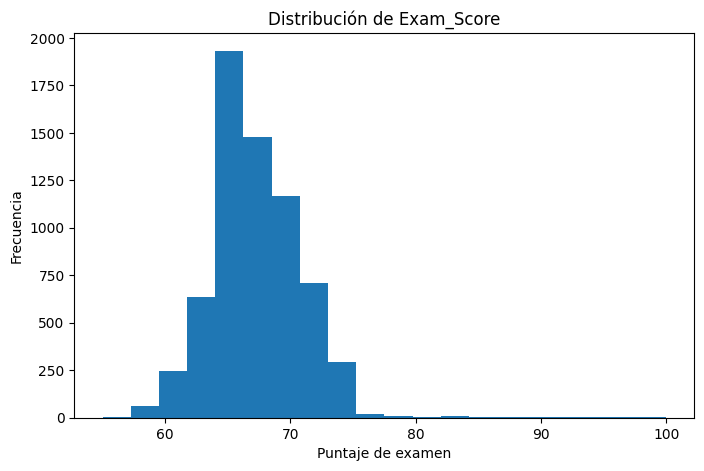

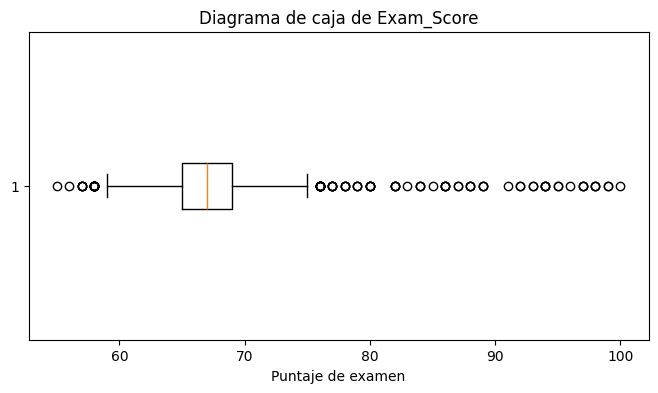

Media: 67.23
Desviación estándar: 3.87
Mínimo: 55
Máximo: 100
Atípicos según regla IQR: 103
Interpretación: la distribución se concentra alrededor de los valores centrales del conjunto. Los valores extremos detectados estadísticamente no se eliminan automáticamente porque pueden representar estudiantes reales; el único valor imposible, 101, ya fue retirado durante la limpieza.


In [13]:
exam_stats = clean['Exam_Score'].describe()
display(exam_stats.to_frame('Exam_Score'))

fig, ax = plt.subplots(figsize=(8,5))
ax.hist(clean['Exam_Score'], bins=20)
ax.set_title('Distribución de Exam_Score')
ax.set_xlabel('Puntaje de examen')
ax.set_ylabel('Frecuencia')
plt.show()

fig, ax = plt.subplots(figsize=(8,4))
ax.boxplot(clean['Exam_Score'], vert=False)
ax.set_title('Diagrama de caja de Exam_Score')
ax.set_xlabel('Puntaje de examen')
plt.show()

q1 = clean['Exam_Score'].quantile(0.25)
q3 = clean['Exam_Score'].quantile(0.75)
iqr = q3-q1
low, high = q1-1.5*iqr, q3+1.5*iqr
stat_outliers = ((clean['Exam_Score'] < low) | (clean['Exam_Score'] > high)).sum()

print(f'Media: {clean.Exam_Score.mean():.2f}')
print(f'Desviación estándar: {clean.Exam_Score.std():.2f}')
print(f'Mínimo: {clean.Exam_Score.min()}')
print(f'Máximo: {clean.Exam_Score.max()}')
print(f'Atípicos según regla IQR: {stat_outliers}')

print('Interpretación: la distribución se concentra alrededor de los valores centrales del conjunto. Los valores extremos detectados estadísticamente no se eliminan automáticamente porque pueden representar estudiantes reales; el único valor imposible, 101, ya fue retirado durante la limpieza.')

## 5. Exploración adicional de variables numéricas y categóricas

Se revisan cuatro variables numéricas (`Hours_Studied`, `Attendance`, `Sleep_Hours` y `Previous_Scores`) y cuatro categóricas (`Parental_Involvement`, `Motivation_Level`, `School_Type` y `Gender`). Esto permite observar distribución, dispersión, valores extremos y balance de categorías.

,count,mean,std,min,25%,50%,75%,max
Hours_Studied,6606.0,19.974266,5.990424,1.0,16.0,20.0,24.0,44.0
Attendance,6606.0,79.974720,11.546219,60.0,70.0,80.0,90.0,100.0
Sleep_Hours,6606.0,7.029216,1.468177,4.0,6.0,7.0,8.0,10.0
Previous_Scores,6606.0,75.067817,14.399184,50.0,63.0,75.0,88.0,100.0


Hours_Studied: rango=1–44, atípicos IQR=43
Attendance: rango=60–100, atípicos IQR=0
Sleep_Hours: rango=4–10, atípicos IQR=0
Previous_Scores: rango=50–100, atípicos IQR=0


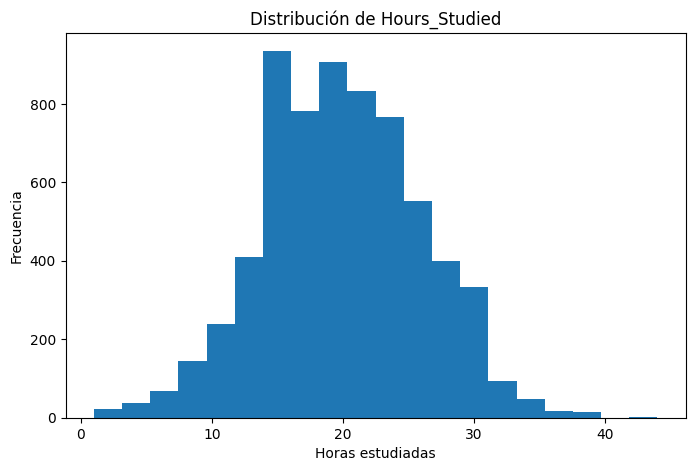

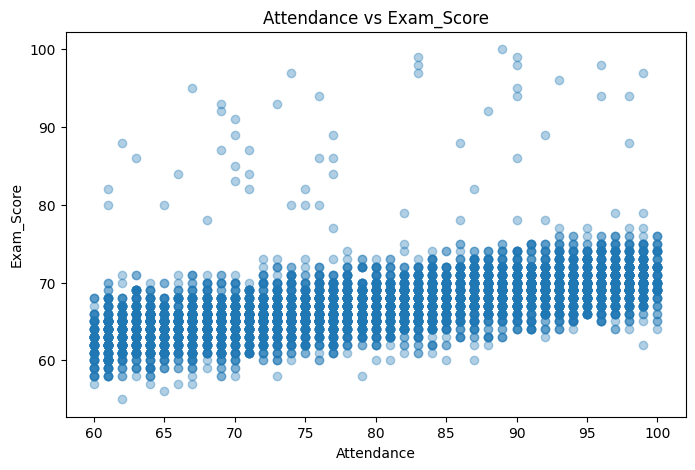

/tmp/ipykernel_3725/650003738.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([clean['Sleep_Hours'], clean['Previous_Scores']], labels=['Sleep_Hours','Previous_Scores'])


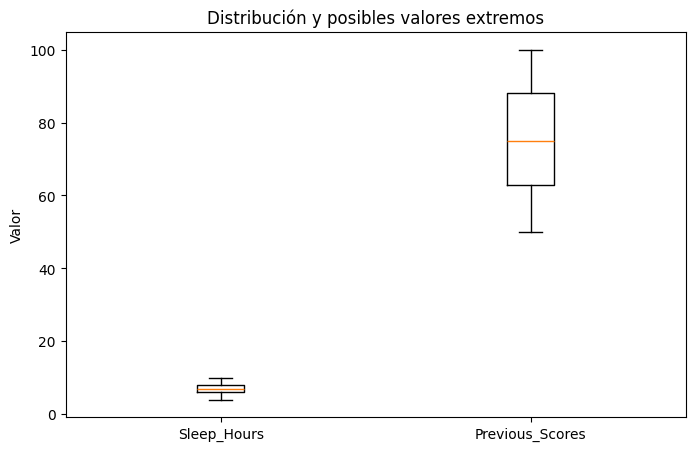

In [14]:
numeric_explore = ['Hours_Studied','Attendance','Sleep_Hours','Previous_Scores']
display(clean[numeric_explore].describe().T)

for c in numeric_explore:
    q1, q3 = clean[c].quantile([0.25,0.75])
    iqr = q3-q1
    lo, hi = q1-1.5*iqr, q3+1.5*iqr
    n_out = ((clean[c] < lo) | (clean[c] > hi)).sum()
    print(f'{c}: rango={clean[c].min()}–{clean[c].max()}, atípicos IQR={n_out}')

fig, ax = plt.subplots(figsize=(8,5))
ax.hist(clean['Hours_Studied'], bins=20)
ax.set_title('Distribución de Hours_Studied')
ax.set_xlabel('Horas estudiadas')
ax.set_ylabel('Frecuencia')
plt.show()

fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(clean['Attendance'], clean['Exam_Score'], alpha=0.35)
ax.set_title('Attendance vs Exam_Score')
ax.set_xlabel('Attendance')
ax.set_ylabel('Exam_Score')
plt.show()

fig, ax = plt.subplots(figsize=(8,5))
ax.boxplot([clean['Sleep_Hours'], clean['Previous_Scores']], labels=['Sleep_Hours','Previous_Scores'])
ax.set_title('Distribución y posibles valores extremos')
ax.set_ylabel('Valor')
plt.show()


Frecuencias de Parental_Involvement:


,frecuencia
Parental_Involvement,
Medium,3362
High,1908
Low,1336


,porcentaje
Parental_Involvement,
Medium,50.89
High,28.88
Low,20.22



Frecuencias de Motivation_Level:


,frecuencia
Motivation_Level,
Medium,3351
Low,1936
High,1319


...

,frecuencia
School_Type,
Public,4597
Private,2009


,porcentaje
School_Type,
Public,69.59
Private,30.41



Frecuencias de Gender:


,frecuencia
Gender,
Male,3814
Female,2792


,porcentaje
Gender,
Male,57.74
Female,42.26


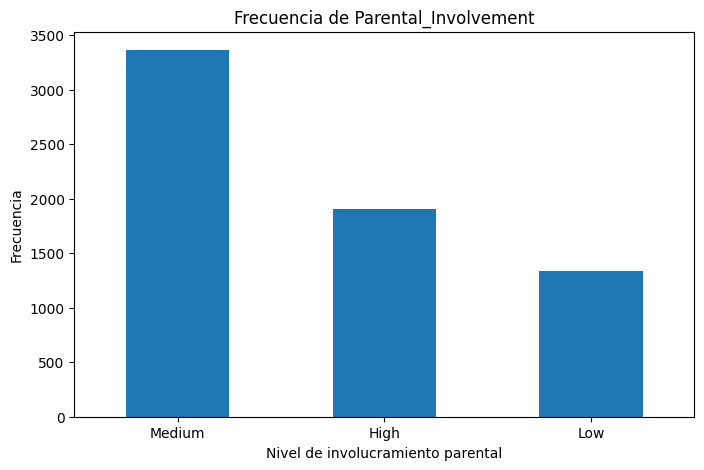

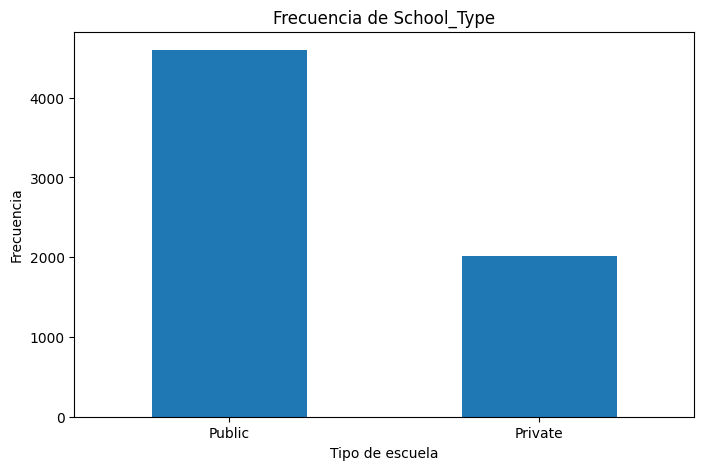

In [15]:
categorical_explore = ['Parental_Involvement','Motivation_Level','School_Type','Gender']

for c in categorical_explore:
    print(f'\nFrecuencias de {c}:')
    display(clean[c].value_counts(dropna=False).to_frame('frecuencia'))
    display((clean[c].value_counts(normalize=True, dropna=False)*100).round(2).to_frame('porcentaje'))

fig, ax = plt.subplots(figsize=(8,5))
clean['Parental_Involvement'].value_counts().plot(kind='bar', ax=ax)
ax.set_title('Frecuencia de Parental_Involvement')
ax.set_xlabel('Nivel de involucramiento parental')
ax.set_ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.show()

fig, ax = plt.subplots(figsize=(8,5))
clean['School_Type'].value_counts().plot(kind='bar', ax=ax)
ax.set_title('Frecuencia de School_Type')
ax.set_xlabel('Tipo de escuela')
ax.set_ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.show()

### Interpretación de las gráficas

- **Hours_Studied:** permite observar la concentración de horas de estudio y detectar observaciones extremas. Los valores altos se conservan porque no existe evidencia suficiente para considerarlos imposibles.
- **Attendance vs Exam_Score:** permite observar visualmente si existe un patrón entre asistencia y desempeño; la gráfica es exploratoria y no demuestra causalidad.
- **Sleep_Hours y Previous_Scores:** el boxplot facilita comparar dispersión y posibles valores extremos entre ambas variables.
- **Parental_Involvement:** permite revisar el balance entre niveles bajo, medio y alto y detectar categorías poco frecuentes o inconsistentes.
- **School_Type:** permite identificar la proporción de registros públicos y privados y comprobar que no existen categorías inesperadas.

## 6. Codificación de variables categóricas

Se utilizará **One-Hot Encoding** para variables nominales, porque sus categorías no tienen un orden natural. En este notebook se aplicará a `School_Type` y `Gender`.

Para variables con un orden claro se utilizará **Ordinal Encoding**. `Parental_Involvement` y `Motivation_Level` se representan como `Low=1`, `Medium=2`, `High=3`. Esta codificación conserva la relación de orden entre categorías, mientras que One-Hot Encoding evita introducir un orden artificial entre categorías nominales.

In [16]:
# Ejemplo explícito de las codificaciones solicitadas
ordinal_cols = ['Parental_Involvement', 'Motivation_Level']
ordinal_categories = [
    ['Low','Medium','High'],
    ['Low','Medium','High']
]

nominal_cols = ['School_Type', 'Gender']

ordinal_encoder = OrdinalEncoder(categories=ordinal_categories)
ordinal_demo = ordinal_encoder.fit_transform(clean[ordinal_cols])
ordinal_demo_df = pd.DataFrame(ordinal_demo, columns=[c+'_ordinal' for c in ordinal_cols])

onehot_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
onehot_demo = onehot_encoder.fit_transform(clean[nominal_cols])
onehot_demo_df = pd.DataFrame(onehot_demo, columns=onehot_encoder.get_feature_names_out(nominal_cols))

print('Ejemplo de Ordinal Encoding:')
display(ordinal_demo_df.head())

print('Ejemplo de One-Hot Encoding:')
display(onehot_demo_df.head())

Ejemplo de Ordinal Encoding:


,Parental_Involvement_ordinal,Motivation_Level_ordinal
0,0.0,0.0
1,0.0,0.0
2,1.0,1.0
3,0.0,1.0
4,1.0,1.0


Ejemplo de One-Hot Encoding:


,School_Type_Private,School_Type_Public,Gender_Female,Gender_Male
0,0.0,1.0,0.0,1.0
1,0.0,1.0,1.0,0.0
2,0.0,1.0,0.0,1.0
3,0.0,1.0,0.0,1.0
4,0.0,1.0,1.0,0.0


## 7. Escalamiento de variables numéricas

Se aplicará `StandardScaler` a `Hours_Studied`, `Attendance`, `Sleep_Hours` y `Previous_Scores`. Esta transformación centra cada variable alrededor de media 0 y la escala según su desviación estándar.

El escalamiento conserva el orden relativo y la información de variación de cada variable, pero cambia sus unidades. Es importante para algoritmos sensibles a la magnitud de las variables, por ejemplo métodos basados en distancias, regresión regularizada y otros modelos que optimizan con variables en diferentes escalas.

In [17]:
scaled_cols = ['Hours_Studied','Attendance','Sleep_Hours','Previous_Scores']

before_scale = clean[scaled_cols].describe().T[['mean','std','min','max']]

scaler = StandardScaler()
scaled_values = scaler.fit_transform(clean[scaled_cols])
after_scale = pd.DataFrame(scaled_values, columns=scaled_cols).describe().T[['mean','std','min','max']]

print('Antes del escalamiento:')
display(before_scale)

print('Después del StandardScaler:')
display(after_scale)

comparison = pd.DataFrame({
    'Hours_Studied_antes': clean['Hours_Studied'].head().values,
    'Hours_Studied_despues': scaled_values[:5,0],
    'Attendance_antes': clean['Attendance'].head().values,
    'Attendance_despues': scaled_values[:5,1]
})
display(comparison)

Antes del escalamiento:


,mean,std,min,max
Hours_Studied,19.974266,5.990424,1.0,44.0
Attendance,79.974720,11.546219,60.0,100.0
Sleep_Hours,7.029216,1.468177,4.0,10.0
Previous_Scores,75.067817,14.399184,50.0,100.0


Después del StandardScaler:


,mean,std,min,max
Hours_Studied,-1.936084e-17,1.000076,-3.167673,4.010994
Attendance,-5.001550e-16,1.000076,-1.730110,1.734489
Sleep_Hours,1.452063e-17,1.000076,-2.063406,2.023604
Previous_Scores,-4.883233e-16,1.000076,-1.741051,1.731631


,Hours_Studied_antes,Hours_Studied_despues,Attendance_antes,Attendance_despues
0,23,0.505133,84,0.348650
1,19,-0.162650,64,-1.383650
2,24,0.672079,98,1.561259
3,29,1.506808,89,0.781725
4,19,-0.162650,92,1.041570


## 8. Pipeline reproducible con ColumnTransformer

Se integrarán en un solo transformador:
- `StandardScaler` para las variables numéricas seleccionadas.
- `OrdinalEncoder` para las variables categóricas ordenadas.
- `OneHotEncoder` para variables nominales.
- Paso directo para variables numéricas que no requieren escalamiento.

**Prevención de fuga de información:** en una etapa real de modelado, el `ColumnTransformer` debe ajustarse (`fit`) únicamente con el conjunto de entrenamiento. Después se aplica (`transform`) al conjunto de validación/prueba. Así, los parámetros aprendidos —por ejemplo medias y desviaciones estándar— no incorporan información del conjunto de prueba.

In [18]:
target = 'Exam_Score'

other_num = ['Tutoring_Sessions', 'Physical_Activity']
other_cat = [
    c for c in clean.select_dtypes(include='object').columns
    if c not in ordinal_cols + nominal_cols
]

preprocessor = ColumnTransformer(
    transformers=[
        ('scaled_num', StandardScaler(), scaled_cols),
        ('other_num', 'passthrough', other_num),
        ('ordinal', OrdinalEncoder(
            categories=ordinal_categories,
            handle_unknown='use_encoded_value',
            unknown_value=-1
        ), ordinal_cols),
        ('nominal', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False
        ), nominal_cols),
        ('other_cat', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False
        ), other_cat)
    ],
    remainder='drop',
    verbose_feature_names_out=False
)

X = clean.drop(columns=[target])
y = clean[target]

X_prepared = preprocessor.fit_transform(X)
feature_names = preprocessor.get_feature_names_out()

prepared = pd.DataFrame(X_prepared, columns=feature_names)
prepared[target] = y.reset_index(drop=True)

print('Dimensiones finales:', prepared.shape)
display(prepared.head())

Dimensiones finales: (6606, 37)


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Parental_Involvement,Motivation_Level,School_Type_Private,School_Type_Public,Gender_Female,Gender_Male,Access_to_Resources_High,Access_to_Resources_Low,Access_to_Resources_Medium,Extracurricular_Activities_No,Extracurricular_Activities_Yes,Internet_Access_No,Internet_Access_Yes,Family_Income_High,Family_Income_Low,Family_Income_Medium,Teacher_Quality_High,Teacher_Quality_Low,Teacher_Quality_Medium,Peer_Influence_Negative,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_No,Learning_Disabilities_Yes,Parental_Education_Level_College,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Far,Distance_from_Home_Moderate,Distance_from_Home_Near,Exam_Score
0,0.505133,0.348650,-0.019901,-0.143617,0.0,3.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,67
1,-0.162650,-1.383650,0.661268,-1.115968,2.0,4.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,61
2,0.672079,1.561259,-0.019901,1.106548,2.0,4.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,74
3,1.506808,0.781725,0.661268,1.592723,1.0,4.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,71
4,-0.162650,1.041570,-0.701069,-0.699247,3.0,4.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,70


## 9. Comparación del estado inicial y final

La comparación resume el efecto de la limpieza y preparación. El número de registros cambia únicamente por la eliminación del registro con `Exam_Score=101` y, si hubiera existido alguno, por duplicados. El número de variables aumenta después de la codificación One-Hot porque una variable categórica se representa mediante varias columnas binarias.

In [19]:
comparison_table = pd.DataFrame({
    'Elemento': [
        'Número de registros',
        'Número de variables',
        'Valores faltantes',
        'Registros duplicados',
        'Variables categóricas transformadas',
        'Variables numéricas escaladas'
    ],
    'Estado inicial': [
        df.shape[0],
        df.shape[1],
        int(df.isna().sum().sum()),
        int(df.duplicated().sum()),
        0,
        0
    ],
    'Estado final': [
        prepared.shape[0],
        prepared.shape[1],
        int(prepared.isna().sum().sum()),
        int(prepared.duplicated().sum()),
        len(ordinal_cols) + len(nominal_cols) + len(other_cat),
        len(scaled_cols)
    ]
})

display(comparison_table)

,Elemento,Estado inicial,Estado final
0,Número de registros,6607,6606
1,Número de variables,20,37
2,Valores faltantes,235,0
3,Registros duplicados,0,0
4,Variables categóricas transformadas,0,13
5,Variables numéricas escaladas,0,4


## 10. Verificación y exportación

Se exportará el dataset preparado en CSV. Se conserva `Exam_Score` como variable objetivo y las demás variables quedan listas para una etapa posterior de modelado.

In [20]:
output_file = 'StudentPerformanceFactors_preparado_modelado.csv'
prepared.to_csv(output_file, index=False)

# Verificación de carga
check = pd.read_csv(output_file)

print('Archivo exportado:', output_file)
print('Dimensiones:', check.shape)
print('Valores faltantes:', int(check.isna().sum().sum()))
print('Duplicados:', int(check.duplicated().sum()))
print('Exam_Score presente:', 'Exam_Score' in check.columns)

display(check.head())

# En Colab, descomenta para descargar:
# from google.colab import files
# files.download(output_file)

Archivo exportado: StudentPerformanceFactors_preparado_modelado.csv
Dimensiones: (6606, 37)
Valores faltantes: 0
Duplicados: 0
Exam_Score presente: True


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Parental_Involvement,Motivation_Level,School_Type_Private,School_Type_Public,Gender_Female,Gender_Male,Access_to_Resources_High,Access_to_Resources_Low,Access_to_Resources_Medium,Extracurricular_Activities_No,Extracurricular_Activities_Yes,Internet_Access_No,Internet_Access_Yes,Family_Income_High,Family_Income_Low,Family_Income_Medium,Teacher_Quality_High,Teacher_Quality_Low,Teacher_Quality_Medium,Peer_Influence_Negative,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_No,Learning_Disabilities_Yes,Parental_Education_Level_College,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Far,Distance_from_Home_Moderate,Distance_from_Home_Near,Exam_Score
0,0.505133,0.348650,-0.019901,-0.143617,0.0,3.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,67
1,-0.162650,-1.383650,0.661268,-1.115968,2.0,4.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,61
2,0.672079,1.561259,-0.019901,1.106548,2.0,4.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,74
3,1.506808,0.781725,0.661268,1.592723,1.0,4.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,71
4,-0.162650,1.041570,-0.701069,-0.699247,3.0,4.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,70


## 11. Conclusión

El análisis inicial mostró 6,607 registros y 20 variables, sin duplicados y con datos numéricos y categóricos. Se encontraron valores faltantes y un Exam_Score de 101, por lo que se realizaron correcciones y se eliminó ese registro inválido.

También se estandarizaron los datos, se trataron los valores faltantes y se aplicaron Ordinal Encoding, One-Hot Encoding y StandardScaler. El dataset quedó preparado para futuros modelos de regresión, conservando Exam_Score como variable objetivo.

Como siguiente paso, sería necesario dividir los datos en entrenamiento y prueba y evaluar un modelo con métricas como MAE, RMSE y R².
